# Target Generation & Hyperparameter Optimization
**Goal:** Identify the optimal labels for training by simulating millions of trades across different parameter sets.
**Key Operations:**
1.  **Swing Detection:** Identifying market swings using `build_signal_per_day`.
2.  **Simulation:** Using `simulate_trading` to test stop-losses, take-profits, and directional signals.
3.  **Optimization:** Using Optuna's **Multivariate TPE** to find the highest reward-to-risk configuration.
**Output:** Saves the best performing parameters to `best_params_target.json`.

In [7]:
# --- SYSTEM PURGE & IMPORTS ---
%reset -f

import gc
import torch
import math
import pandas as pd
import numpy as np
import optuna
import importlib
import os
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from optuna.samplers import TPESampler

# 1. Clear GPU/CPU memory
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# 2. Import Custom Libraries
from libs import preps, opts, params, feats, strats

# 3. Handle Reloads
importlib.reload(preps)
importlib.reload(opts)
importlib.reload(params)
importlib.reload(feats)
importlib.reload(strats)

# 4. Standardize Display
pd.set_option('display.max_columns', None)
plt.ioff() # Prevent thousands of plots from popping up during Optuna

print(f"🚀 Environment Ready. Sampler initialized for {params.ticker}")

🚀 Environment Ready. Sampler initialized for AAPL


✅ Data Loaded: 350711 rows ready for Optuna.


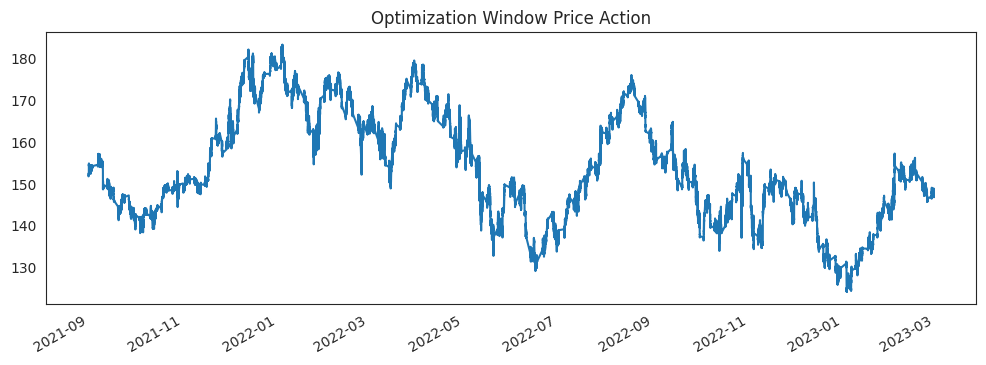

In [8]:
col_signal = "targ_signal"

cols_needed = [
    "open", "high", "low", "close", "volume", "trade_count", "vwap", "ask", "bid",
    params.col_atr_tick, params.col_adx_tick, params.col_rsi_tick, params.col_vwap_tick,
]

df_inds = pd.read_parquet(params.indunsc_parquet, columns=cols_needed)

# Filter for the optimization window (Localizing to UTC for consistency)
df_inds.index = pd.to_datetime(df_inds.index).tz_localize(None)
df_inds = df_inds[(df_inds.index >= params.start_date_sim) & (df_inds.index < params.end_date_sim)]

print(f"✅ Data Loaded: {len(df_inds)} rows ready for Optuna.")

plt.figure(figsize=(12, 4))
df_inds['close'].plot(title="Optimization Window Price Action")
plt.show()

In [9]:
# 'min_prof_thr': (0.05121694481444561, 0.0540030551855544),
#  'max_down_prop': (0.6061460846109266, 0.6528539153890733),
#  'gain_tightfact': (3.413540213653459, 3.906769786346541),
#  'tau_time': (48.68093278481928, 56.27504721518072),
#  'tau_dur': (63.226961893902214, 96.20824810609777),
#  'thresh_choice': {'categorical': ['median_nonzero']},
#  'rsi_min_thresh': (100, 100),
#  'rsi_max_thresh': (0, 0),
#  'adx_thresh': (14.997572471754179, 15.010627528245823),
#  'trailstop_pct': (0.5514958648622245, 1.1971241351377757),
#  'atr_mult': (0.9825906210150942, 1.0213893789849056),
#  'vwap_atr_mult': (-26.18259943397927, -21.987110566020732),
#  'buy_factor': (4.567450915287415, 5.7567990847125845),
#  'sell_factor': (3.100200713316168, 5.770769286683832)}

In [10]:
def objective(trial: optuna.Trial) -> float:
    # --- 1. Swing Detection (Oracle) ---
    min_prof_thr    = trial.suggest_float("min_prof_thr", 0.05, 0.07)      # Min 0.05 (ML Predictability)
    max_down_prop   = trial.suggest_float("max_down_prop", 0.6, 0.7)      
    gain_tightfact  = trial.suggest_float("gain_tightfact", 3.0, 4.5)    
    tau_time        = trial.suggest_float("tau_time", 45.0, 60.0)
    tau_dur         = trial.suggest_float("tau_dur", 60.0, 100.0)

    # --- 2. Thresholding Logic ---
    thresh_choice   = trial.suggest_categorical("thresh_choice", ["median_nonzero"])
    if thresh_choice == "numeric":
        thresh_mode = trial.suggest_float("thresh_value", 0.0, 2.0)
    else:
        thresh_mode = thresh_choice
    thresh_window = 0 

    # --- 3. Strategy Filters ---
    rsi_min_thresh  = trial.suggest_float("rsi_min_thresh", 100.0, 100.0)
    rsi_max_thresh  = trial.suggest_float("rsi_max_thresh", 0.0, 0.0)
    
    adx_thresh      = trial.suggest_float("adx_thresh", 15.0, 15.0)       # Min 15.0 (ML Predictability)
    trailstop_pct   = trial.suggest_float("trailstop_pct", 0.5, 1.5)      # Min 0.02 (Tick Size)
    atr_mult        = trial.suggest_float("atr_mult", 1.0, 1.0)           # Min 1.0 (ML Predictability)
    
    vwap_atr_mult   = trial.suggest_float("vwap_atr_mult", -30.0, -20.0)
    
    # --- 4. Position Sizing ---
    buy_factor      = trial.suggest_float("buy_factor", 4.0, 6.0)
    sell_factor     = trial.suggest_float("sell_factor", 3.0, 6.0)

    print("-" * 160)
    print("Params => " + "; ".join(f"{k}={v}" for k, v in dict(trial.params).items()))

    # 2. Build signal and apply thresholds (Pre-processing)
    df_build = preps.build_signal_per_day(
        df              = df_inds.copy(),
        min_prof_thr    = min_prof_thr,
        max_down_prop   = max_down_prop,
        gain_tightfact  = gain_tightfact,
        tau_time        = tau_time,
        tau_dur         = tau_dur,
        col_close       = "close",
    )

    df_thresh = preps.apply_thresholds_per_day(
        df              = df_build,
        thresh_mode     = thresh_mode,
        thresh_window   = thresh_window,
        col_signal      = col_signal
    )

    # Reset global state for the trial
    start_ask = df_thresh["ask"].iat[0]
    strats.reset_globals(start_ask)

    groups = list(df_thresh.groupby(df_thresh.index.normalize()))
    pbar = tqdm(groups, total=len(groups), desc=f"Trial {trial.number}", leave=False)
    acc = opts.TrialAccumulator(trial, pbar, report_interval=report_interval, prun_perc=prun_perc)
    
    for step, (day, df_day) in enumerate(pbar, 1):
        # 3. Call generate_actions with the full parameter set
        df_actions = strats.generate_actions(
            df              = df_day,
            col_signal      = col_signal,
            sign_thresh     = "signal_thresh",
            col_atr         = params.col_atr_tick,
            col_adx         = params.col_adx_tick,
            col_rsi         = params.col_rsi_tick,
            col_vwap        = params.col_vwap_tick,
            rsi_min_thresh  = rsi_min_thresh,
            rsi_max_thresh  = rsi_max_thresh,
            adx_thresh      = adx_thresh,
            trailstop_pct   = trailstop_pct,
            atr_mult        = atr_mult,
            vwap_atr_mult   = vwap_atr_mult,
            buy_factor      = buy_factor,
            sell_factor     = sell_factor,
            col_close       = "close"
        )

        # 4. Call simulate_trading with ONLY day and df as required
        sim_results = strats.simulate_trading(
            day             = day,
            df              = df_actions
        )

        acc.process(sim_results, step, parse_eq_value_callable=strats._parse_eq_value)
        
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

        del df_actions, sim_results

    return acc.finalize()


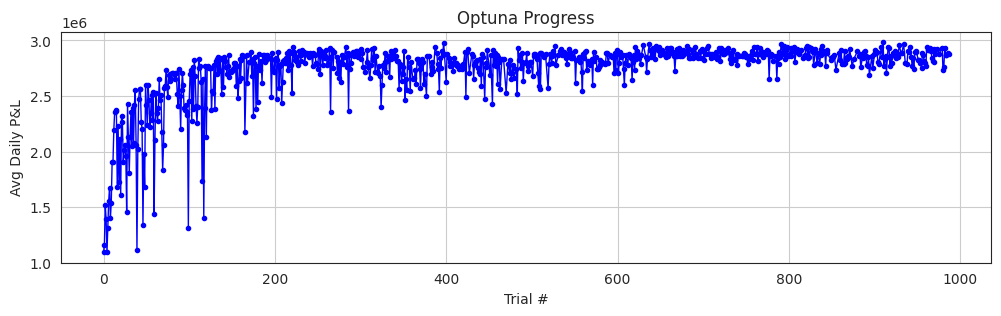

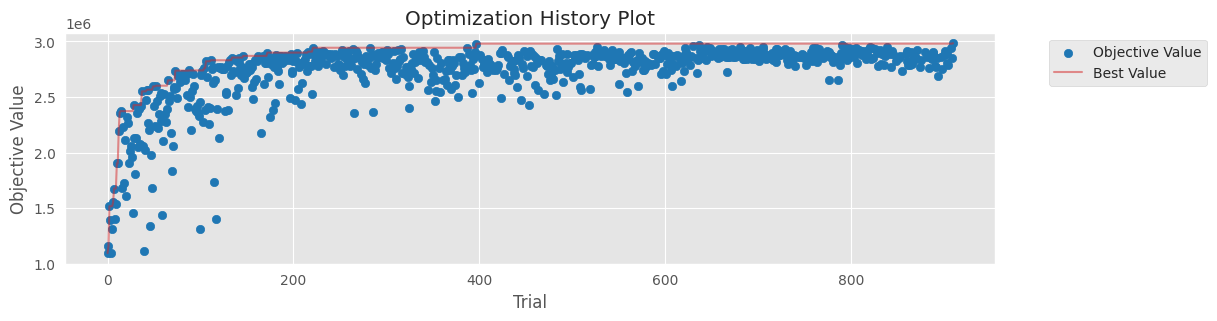

----------------------------------------------------------------------------------------------------------------------------------------------------------------
Params => min_prof_thr=0.06950931685976265; max_down_prop=0.6783270080182942; gain_tightfact=3.603557742767573; tau_time=52.100677948835525; tau_dur=73.45013943158187; thresh_choice=median_nonzero; rsi_min_thresh=100.0; rsi_max_thresh=0.0; adx_thresh=15.0; trailstop_pct=1.0533221047212193; atr_mult=1.0; vwap_atr_mult=-29.017569862787013; buy_factor=5.810515941337847; sell_factor=4.1393606049790765


Trial 0:   0%|          | 0/375 [00:00<?, ?it/s]

[Results] mean_pnl:1094872.0734 mean_bh:-8.7491 mean_excess:1094880.8225 improv_vs_bh:12514228.03%
Action counts: {'Buy': 4745, 'Sell': 5077, 'Hold': 340889}
Best trial is: 0 with best_val: 1094880.8225
[save_results] wrote optuna_results/AAPL_1094880.8225_target.csv
[save_best_json] wrote optuna_results/AAPL_1094880.8225_target.json
----------------------------------------------------------------------------------------------------------------------------------------------------------------
Params => min_prof_thr=0.0656450129154767; max_down_prop=0.6123799416852308; gain_tightfact=3.138655269838087; tau_time=46.629065974156475; tau_dur=74.05530588360517; thresh_choice=median_nonzero; rsi_min_thresh=100.0; rsi_max_thresh=0.0; adx_thresh=15.0; trailstop_pct=0.9011578573615127; atr_mult=1.0; vwap_atr_mult=-22.634805884679878; buy_factor=5.477507883152223; sell_factor=3.001203130537099


Trial 1:   0%|          | 0/375 [00:00<?, ?it/s]

[Results] mean_pnl:1158422.3600 mean_bh:-8.7491 mean_excess:1158431.1091 improv_vs_bh:13240592.72%
Action counts: {'Buy': 4895, 'Sell': 5537, 'Hold': 340279}
Best trial is: 1 with best_val: 1158431.1091
[save_results] wrote optuna_results/AAPL_1158431.1091_target.csv
[save_best_json] wrote optuna_results/AAPL_1158431.1091_target.json


...

[Results] mean_pnl:2878431.0314 mean_bh:-8.7491 mean_excess:2878439.7805 improv_vs_bh:32899883.74%
Action counts: {'Buy': 5270, 'Sell': 4931, 'Hold': 340510}
Best trial is: 910 with best_val: 2984233.0340
----------------------------------------------------------------------------------------------------------------------------------------------------------------
Params => min_prof_thr=0.05131235231384945; max_down_prop=0.6102117191041453; gain_tightfact=3.146256506209658; tau_time=45.41823785985943; tau_dur=71.25576043163619; thresh_choice=median_nonzero; rsi_min_thresh=100.0; rsi_max_thresh=0.0; adx_thresh=15.0; trailstop_pct=1.0191397858713662; atr_mult=1.0; vwap_atr_mult=-28.22365898914348; buy_factor=4.15217834524182; sell_factor=3.238126058962498


Trial 988:   0%|          | 0/375 [00:00<?, ?it/s]

[PRUNE] value=14593.474620 thr=18049.407335
[Results] mean_pnl:14693.4161 mean_bh:99.9415 mean_excess:14593.4746 improv_vs_bh:14602.01%
Action counts: {'Buy': 2116, 'Sell': 2189, 'Hold': 136008}
Best trial is: 910 with best_val: 2984233.0340
----------------------------------------------------------------------------------------------------------------------------------------------------------------
Params => min_prof_thr=0.050676674505895615; max_down_prop=0.688919036284289; gain_tightfact=3.1013381078101423; tau_time=46.67708683186638; tau_dur=68.48493006181961; thresh_choice=median_nonzero; rsi_min_thresh=100.0; rsi_max_thresh=0.0; adx_thresh=15.0; trailstop_pct=0.954152280104466; atr_mult=1.0; vwap_atr_mult=-28.56365542787983; buy_factor=4.1058264272844625; sell_factor=5.90097638801895


Trial 989:   0%|          | 0/375 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [11]:
report_interval   = 50
prun_perc         = 80
n_startup_trials  = 150
n_trials          = 3000

opts.init_optuna_displays()
optuna.logging.set_verbosity(optuna.logging.ERROR)

# sampler = optuna.samplers.TPESampler(n_startup_trials=250, multivariate=True)

pruner  = optuna.pruners.PercentilePruner(
    percentile=prun_perc, 
    n_startup_trials=n_startup_trials, 
    n_warmup_steps=math.ceil(math.ceil(len(list(df_inds.groupby(df_inds.index.normalize()))) / report_interval) * 0.3)
)

study = optuna.create_study(pruner=pruner, 
                            # sampler=sampler, 
                            direction="maximize")

study.optimize(
    objective,
    n_trials=n_trials,
    callbacks=[opts.plot_callback, opts.short_log_callback, 
               opts.make_save_results_callback("target"), 
               opts.make_save_best_json_callback("target")],
    gc_after_trial=True
)